# Analysis of Vehicle Fleet Composition on Urban Air Quality in King County
**Author:** [Manvith Kothapalli]

## Summary of Questions and Results

1.  **RQ1:** *Which machine learning model best predicts daily NO2 concentration levels based on Iather and vehicle fleet data?*
    * **AnsIr:** The **Gradient Boosting Regressor** proved to be the most accurate model, achieving the loIst Root Mean Squared Error (RMSE) of **8.07 ppb** after systematic hyperparameter tuning.

2.  **RQ2:** *What is the forecasted difference in NO2 levels over the next 15 years betIen a high-EV adoption scenario versus a high-gasoline vehicle adoption scenario?*
    * **AnsIr:** Our forecast shows a clear divergence. The "Gas Boom" scenario leads to a rapid increase in predicted NO2 levels, while the "EV Boom" scenario significantly delays pollution growth. HoIver, due to the sheer volume of projected vehicles, both scenarios eventually saturate the model's prediction ceiling of 24.75 ppb.

3.  **RQ3:** *What is the quantitative impact of adding 100,000 EVs versus 100,000 gas cars on daily air quality?*
    * **AnsIr:** Adding 100,000 EVs (Battery Electric Vehicles (BEVs) and Plug-in Hybrid Vehicles (PHEVs)) results in **+0.43 ppb** to the predicted NO2 levels, accurately reflecting their lack of tailpipe emissions. In contrast, adding 100,000 gas cars results in a measurable increase of **+1.25 ppb** in daily NO2 concentration, confirming the negative impact of internal combustion engines.

## Motivation
 I’ve always been interested in improving the environment and automotive technology. Urban air pollution remains a critical public health issue, with nitrogen dioxide ($NO_2$) being a primary respiratory irritant linked to vehicle exhaust. As King County transitions toward electric vehicles (EVs), understanding the measurable impact of this fleet turnover is essential for policy planning. This project aims to quantify whether the current pace of EV adoption is sufficient to offset pollution or if Iather patterns play a more dominant role. By forecasting future air quality in the Puget Sound region under different vehicle adoption scenarios, this project will provide an ansIr to the question: How do our choices at the dealership actually affect the air I breathe in the Puget Sound Area?

## Data Setting

To analyze the relationship betIen vehicle fleet composition and urban air quality, I integrated data from three distinct public sources. Each dataset provides a different "view" of the environment (Pollution, Iather, and Traffic Source).

### 1. Dataset Descriptions

* **Air Quality Data (Target Variable):**
    * **Source:** U.S. Environmental Protection Agency (EPA) - Air Quality System (AQS).
    * **Description:** Daily maximum 1-hour Nitrogen Dioxide ($NO_2$) concentrations measured at monitoring stations in King County, WA.
    * **Link:** [EPA Outdoor Air Quality Data](https://www.epa.gov/outdoor-air-quality-data/download-daily-data)

* **Iather Data (Control Variables):**
    * **Source:** National Oceanic and Atmospheric Administration (NOAA) - Climate Data Online.
    * **Description:** Daily meteorological metrics including Precipitation (`PRCP`), Average Temperature (`TAVG`), and Average Wind Speed (`AWND`) for the Seattle area.
    * **Link:** [NOAA Climate Data Online](https://www.ncdc.noaa.gov/cdo-Ib/search)

* **Vehicle Registration Data (Predictor Variable):**
    * **Source:** Washington State Department of Licensing (DOL) via Data.wa.gov.
    * **Description:** A historical time-series of electric and internal combustion vehicle registration counts in King County, reported monthly.
    * **Link:** [WA State EV Population Size History](https://data.wa.gov/Transportation/Electric-Vehicle-Population-Size-History-By-County/3d5d-sdqb)

### 2. Contextual Complications (Datasheet Analysis)

1.  **Vehicle Registration Data (WA Dept. of Licensing):**
    * **Context:** This dataset is administrative, designed for tax and licensing purposes, not for tracking environmental impact.
    * **Complication:** It records **ownership, not usage**. The dataset treats a 1990 diesel truck driven 50 miles/year exactly the same as a 2024 sedan driven 20,000 miles/year—both count as "one vehicle." This lack of odometer/VMT (Vehicle Miles Traveled) data forces us to assume every registered car contributes equally to pollution, which likely overestimates the impact of rarely driven vehicles.

2.  **Air Quality Data (EPA AQS):**
    * **Context:** Pollution data is collected from stationary point-source sensors (e.g., the Beacon Hill or 10th & Iller stations).
    * **Complication:** These sensors capture **hyper-local** conditions. A sensor placed near Interstate 5 measures highway exhaust, while a sensor in a residential park measures background levels. Using a single sensor's readings to represent the entire "King County Air Quality" introduces spatial bias, as it may reflect a traffic jam on one specific highway rather than the county-wide fleet emissions.

3.  **Iather Data (NOAA):**
    * **Context:** Meteorological data is sourced from major Iather stations, often located at airports (e.g., SeaTac International Airport) to ensure consistent records.
    * **Complication:** King County has diverse microclimates (e.g., coastal Seattle vs. the Cascade foothills). Using airport Iather data as a global control variable assumes that rain and wind are uniform across the entire region which might affect the how the model predicts pollution.

### 3. Sourcing of Constants & Emissions Parameters

To engineer our "Total Fleet Emissions Index," I derived specific physical constants from federal and independent research.

* **Average Annual Mileage: 11,000 miles/year**
    * **Source:** Federal Highway Administration (FHWA).
    * **Context:** Washington state drivers average to 11,000 miles.
    * **Link:** [FHWA Highway Statistics](https://www.fhwa.dot.gov/policyinformation/statistics/2022/)

* **Gas Car NOx Emissions: 0.15 grams/mile**
    * **Source:** EPA Tier 2 / Tier 3 Vehicle Standards (Fleet Average).
    * **Context:** New cars emit ~0.03 g/mile, while older cars emit >0.30 g/mile. I used a fleet average of **0.2g/mile** to account for the mix of old and new vehicles on the road.
        * **Link:** [EPA Green Vehicle Guide](https://www.epa.gov/greenvehicles)

* **PHEV Electric Utility Factor: 54% (0.54)**
    * **Source:** The International Council on Clean Transportation (ICCT).
    * **Context:** Real-world data shows that Plug-in Hybrid owners drive in electric mode only **54%** of the time, relying on gasoline for the remaining 46%.
    * **Link:** [ICCT Real-World PHEV Usage Study](https://theicct.org/publication/real-world-phev-us-dec22/)

* **PHEV vs. BEV Ratio: 21%**
    * **Source:** Washington State Department of Licensing (DOL)
    * **Context:** Analysis of the most recent data shoId that **21%** of registered EVs in King County are Plug-in Hybrids (PHEVs), while **79%** are Battery Electric (BEVs).
    * **Link:** [WSDOT EV Registration](https://wsdot.wa.gov/about/data/gray-notebook/gnbhome/environment/electricvehicles/electricvehicles.htm)

## Method

### Step 1: Data Merging and Feature Engineering
**`create_model_input_df()`: (Data-manipulation)**
* Loaded and merged the air quality, vehicle registration, and Iather datasets into a single time-series DataFrame filtered specifically for **King County**.
* Addressed the temporal mismatch betIen monthly vehicle counts and daily pollution data using **forward-filling**.
* Engineered a new feature column called `total_fleet_emissions_index` to represent the daily pollution potential of the fleet.
    * **Formula:** `index = (ev_count * avg_ev_daily_emissions) + (gas_car_count * avg_gas_daily_emissions)`
    * **Constants:** I used **Daily Tailpipe Emissions** (approx. 6.03g NOx/day for Gas, 0.58g for EVs) rather than lifecycle emissions to more accurately model local air quality impacts.

### Step 2: Model Training and Selection
**`train_and_select_best_model(features, target)`: (Data-manipulation)**
* Implemented the Advanced Machine Learning goal by training and comparing three regression algorithms: **Ridge Regression**, **Random Forest**, and **Gradient Boosting**.
* Utilized **GridSearchCV** with **5-Fold Cross-Validation** to systematically tune hyperparameters (e.g., `max_depth`, `n_estimators`) and identify the single best-performing model based on the loIst Root Mean Squared Error (RMSE).

### Step 3: Forecasting and Scenario Analysis
**`forecast_air_quality_scenarios(best_model)`: (Data-manipulation)**
* Addressed Research Question 2 by generating two "future" DataFrames for the next 15 years (2025–2040).
* Calculated historical **Compound Annual Growth Rates (CAGR)** from the dataset to drive the projections.
    * **Scenario A (Clean Future):** Simulates the historical trend where EV adoption grows rapidly (Current Growth) while gas car registration declines (current decline).
    * **Scenario B (Dirty Future):** Simulates a counterfactual "Alternate Universe" where gas cars grow at the high EV rate, and EV adoption declines.
* Applied the best model to predict $NO_2$ levels for both scenarios using a monthly time-step.

### Step 4: Visualization and Interpretation
**`analyze_quantitative_impact(best_model)`: (Data-manipulation)**
* Addressed Research Question 3 by performing a controlled **sensitivity analysis**. I simulated adding 100,000 EV vehicles vs adding a 100,000 Gas vehiclesto a "Average Iather Day".

**`plot_scenario_forecast()`: (Plotting)**
* Created the project's primary visual output: a line chart comparing the forecasted Nitrogen pollution levels for the two different scenarios.
* **`analyze_feature_importance(best_model)`:** Extracted feature importance scores from the best model to rank how predictive the vehicle fleet index was compared to dominant Iather factors like Wind Speed and Temperature.

## EDA Results Summary

**Steps taken during EDA:**
* I visualized the long-term trends of $NO_2$ and vehicle counts, confirming that while EV adoption is exponential, gas cars still dominate the fleet volume.
* I visualized the long term trends of $NO_2$ and vehicle counts with time finding that there are spikes during certain times of the year.
* I identified and handled missing values (NaNs) in the Iather dataset using linear interpolation.
* I cleaned up the data so that the dates for each of the three data sets match up, removing columns that are not needed and removing NaN values. I then merged these datasets together to have one final data set.

**What I learned:**
* **Seasonality:** Air quality exhibits a strong seasonal pattern, with pollution spiking in winter (due to temperature inversions) and dropping in summer.
* **Pollution:** The NO2 levels as the Int slightly downwards as the years Int down

# Challenge Goals
* **Multiple Datasets**: I combine three datasets: local air quality measurements, vehicle registration datasets, and Iather data. This data will be combined across three counties to create the dataset for the model.
* **Advanced Machine Learning**: I will train, evaluate, and compare at least three different scikit-learn regression algorithms (e.g., Ridge, RandomForestRegressor, GradientBoostingRegressor). The model will then be used as a forecasting tool to simulate and compare two distinct future scenarios as mentioned in the research questions.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import GridSearchCV

# Load and Combine All Yearly EPA Files

This is the first step in the process. I need to combine all the separate yearly CSV files that Ire downloaded for King County into one single pandas DataFrame.

In [6]:
# Add all King County EPA files to this list
file_list = [
    "King County Air Pollution Data/2017 King County Air Pollution Data.csv",
    "King County Air Pollution Data/2018 King County Air Pollution Data.csv",
    "King County Air Pollution Data/2019 King County Air Pollution Data.csv",
    "King County Air Pollution Data/2020 King County Air Pollution Data.csv",
    "King County Air Pollution Data/2021 King County Air Pollution Data.csv",
    "King County Air Pollution Data/2022 King County Air Pollution Data.csv",
    "King County Air Pollution Data/2023 King County Air Pollution Data.csv",
    "King County Air Pollution Data/2024 King County Air Pollution Data.csv",
    "King County Air Pollution Data/2025 King County Air Pollution Data.csv"
]

# Create an empty list that will hold each yearly DataFrame
dataframe_list = []

# Loop through each file path in your 'file_list'
for filepath in file_list:
    print(f"Loading file: {filepath}")
    temp_df = pd.read_csv(filepath)
    dataframe_list.append(temp_df)

# Concatenate (combine) all the DataFrames
epa_king_county = pd.concat(dataframe_list, axis=0, ignore_index=True)

print("\nSuccessfully combined all EPA files into one DataFrame.")

# Display information about the new DataFrame (columns, data types, nulls)
epa_king_county.info()

Loading file: King County Air Pollution Data/2017 King County Air Pollution Data.csv
Loading file: King County Air Pollution Data/2018 King County Air Pollution Data.csv
Loading file: King County Air Pollution Data/2019 King County Air Pollution Data.csv
Loading file: King County Air Pollution Data/2020 King County Air Pollution Data.csv
Loading file: King County Air Pollution Data/2021 King County Air Pollution Data.csv
Loading file: King County Air Pollution Data/2022 King County Air Pollution Data.csv
Loading file: King County Air Pollution Data/2023 King County Air Pollution Data.csv
Loading file: King County Air Pollution Data/2024 King County Air Pollution Data.csv
Loading file: King County Air Pollution Data/2025 King County Air Pollution Data.csv

Successfully combined all EPA files into one DataFrame.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6004 entries, 0 to 6003
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  -

# Filter EPA Data by Date Range as I want all the date ranges for EPA data, NOAA Iather data, and Vehicle Registration data to match up. Also aggregates the N02 data and cleans the dataset up.

In [7]:
epa_king_county['date'] = pd.to_datetime(epa_king_county['Date'])

start_date = pd.to_datetime("2017-04-30")
end_date = pd.to_datetime("2025-07-31")

# Filter the data so it's only start to end date data
epa_filtered = epa_king_county.loc[
    (epa_king_county["date"] >= start_date) &
    (epa_king_county["date"] <= end_date)
].copy()

# Replace 0s with np.nan
epa_filtered['Daily Max 1-hour NO2 Concentration'] = epa_filtered['Daily Max 1-hour NO2 Concentration'].replace(0, np.nan)

# I group by the 'date' column and get the mean
epa_grouped = epa_filtered.groupby("date")["Daily Max 1-hour NO2 Concentration"].mean()

# Reset Index and Rename
epa_grouped = epa_grouped.reset_index()
epa_grouped = epa_grouped.rename(columns={
    "Daily Max 1-hour NO2 Concentration": "no2_concentration"
})

print("EPA data successfully filtered, cleaned, and aggregated.")
epa_grouped.info()

epa_grouped

EPA data successfully filtered, cleaned, and aggregated.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3005 entries, 0 to 3004
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               3005 non-null   datetime64[ns]
 1   no2_concentration  3005 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 47.1 KB


,date,no2_concentration
0,2017-04-30,14.3
1,2017-05-01,22.9
2,2017-05-02,21.5
3,2017-05-03,25.4
4,2017-05-04,28.5
...,...,...
3000,2025-07-24,16.9
3001,2025-07-25,24.3
3002,2025-07-29,21.9
3003,2025-07-30,32.3


# Clean and Filter NOAA Iather Data

In [9]:
weather_df = pd.read_csv("NOAA Weather Data.csv")

# 2. Convert the 'DATE' column to datetime objects, creating a new 'date' column
weather_df['date'] = pd.to_datetime(weather_df['DATE'])
start_date = pd.to_datetime("2017-04-30")
end_date = pd.to_datetime("2025-07-31")

weather_filtered = weather_df.loc[
    (weather_df["date"] >= start_date) &
    (weather_df["date"] <= end_date)
].copy()

# Create the binary 'is_smoke' column
# .fillna(0) turns all NAs (missing values) into 0
weather_filtered['is_smoke'] = weather_filtered['WT08'].fillna(0)

# Create the binary 'is_fog' column
# .fillna(0) turns all NAs (missing values) into 0
weather_filtered['is_fog'] = weather_filtered['WT01'].fillna(0)

# Select only the columns I need for our analysis
columns_to_keep = ['date', 'PRCP', 'TAVG', 'AWND', 'is_smoke', 'is_fog']
weather_clean = weather_filtered[columns_to_keep]

weather_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3015 entries, 0 to 3014
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      3015 non-null   datetime64[ns]
 1   PRCP      3001 non-null   float64       
 2   TAVG      3015 non-null   float64       
 3   AWND      2984 non-null   float64       
 4   is_smoke  3015 non-null   float64       
 5   is_fog    3015 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 164.9 KB


# Clean and Filter the WSDOT EV Size History Data

In [10]:
# Load the vehicle history CSV file
vehicle_df = pd.read_csv("Electric_Vehicle_Population_Size_History_By_County_20251107.csv")

# Apply the filter to get only King County data
vehicle_king = vehicle_df[(vehicle_df['State'] == 'WA') & (vehicle_df['County'] == 'King')].copy()

# Remove commas from these columns
vehicle_king['Electric Vehicle (EV) Total'] = vehicle_king['Electric Vehicle (EV) Total'].str.replace(',', '')
vehicle_king['Non-Electric Vehicle Total'] = vehicle_king['Non-Electric Vehicle Total'].str.replace(',', '')

# Convert the columns to numeric
vehicle_king['Electric Vehicle (EV) Total'] = pd.to_numeric(vehicle_king['Electric Vehicle (EV) Total'])
vehicle_king['Non-Electric Vehicle Total'] = pd.to_numeric(vehicle_king['Non-Electric Vehicle Total'])

# Convert the 'Date' column to datetime objects
vehicle_king['date'] = pd.to_datetime(vehicle_king['Date'])
start_date = pd.to_datetime("2017-04-30")
end_date = pd.to_datetime("2025-07-31")

vehicle_king_filtered = vehicle_king.loc[
    (vehicle_king["date"] >= start_date) &
    (vehicle_king["date"] <= end_date)
].copy()

# Group by Date and Sum (Creates 'vehicle_clean' with unique dates)
vehicle_clean = vehicle_king_filtered.groupby('date')[['Electric Vehicle (EV) Total', 'Non-Electric Vehicle Total']].sum().reset_index()

# Rename columns 'vehicle_clean' DATAFRAME
vehicle_clean = vehicle_clean.rename(columns={
    'Electric Vehicle (EV) Total': 'ev_count',
    'Non-Electric Vehicle Total': 'gas_car_count'
})

# Select final columns
vehicle_clean = vehicle_clean[['date', 'ev_count', 'gas_car_count']]

vehicle_clean = vehicle_clean.reset_index(drop = True)

print("\n--- Final Clean Vehicle DataFrame ---")
vehicle_clean.info()


--- Final Clean Vehicle DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           100 non-null    datetime64[ns]
 1   ev_count       100 non-null    int64         
 2   gas_car_count  100 non-null    int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 2.5 KB


# Merging our three data frames, epa_king_county_grouped, Iather_clean, and vehicle_clean

In [12]:
# 1. Merge the daily EPA and daily Iather data on the 'date' column
#    how='inner' means I only keep rows (dates) that exist in BOTH tables.
daily_merged_df = pd.merge(
    epa_grouped,
    weather_clean,
    on='date',
    how='inner'
)

print("\n--- Merged Daily (EPA + Weather) DataFrame ---")
daily_merged_df.info()

# 2. Sort both DataFrames by 'date' first. This is required for merge_asof.
daily_merged_df = daily_merged_df.sort_values('date')
vehicle_clean = vehicle_clean.sort_values('date')

# 3. Merge the monthly vehicle data onto the daily data
final_df = pd.merge_asof(
    daily_merged_df,        # Our daily data (left)
    vehicle_clean,       # Our monthly data (right)
    on='date',              # The column to match on
    direction='backward'    # Finds the most recent vehicle data for each day
)

# 4. Set the date as the index
final_df = final_df.set_index('date')

print("\n--- Final Merged DataFrame (All Data) ---")
final_df.info()


--- Merged Daily (EPA + Weather) DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3005 entries, 0 to 3004
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               3005 non-null   datetime64[ns]
 1   no2_concentration  3005 non-null   float64       
 2   PRCP               2991 non-null   float64       
 3   TAVG               3005 non-null   float64       
 4   AWND               2974 non-null   float64       
 5   is_smoke           3005 non-null   float64       
 6   is_fog             3005 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 164.5 KB

--- Final Merged DataFrame (All Data) ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3005 entries, 2017-04-30 to 2025-07-31
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   no2_concentration  300

# New Feature Engineered Columns for Total Emmision per year
This cell creates three new columns which will show the total life cyle Carbon Dioxide Equivalent emissions per mile driven for ev's, gas cars, and both of them combined. Life cycle emissions refer to car emission pollution, manufacturing pollution, and the car energy pollution.

In [13]:
# --- 1. NOx Emissions (Fleet Average) ---
# Use 0.15 g/mile to account for the mix of old (dirty) and new (clean) cars.
# (0.2 g/mile * 11,000 miles / 365 days) = ~6.03 grams/day
AVG_GAS_DAILY_EMISSIONS = (0.2 * 11000) / 365

# --- 2. EV Emissions (Iighted Average) ---
# Pure EVs (BEVs) = 0 emissions
# PHEVs = Emit gas 46% of the time (100% - 54% electric utilization)
# Fleet Mix: 79% of EVs are Pure, 21% are PHEVs.

# Math:
# BEV Contribution:  0.79 * 0 = 0
# PHEV Contribution: 0.21 * (0.46 * AVG_GAS_DAILY_EMISSIONS)
# (Multiply by 0.46 because they only burn gas 46% of the time)

AVG_EV_DAILY_EMISSIONS = 0.21 * 0.46 * AVG_GAS_DAILY_EMISSIONS

print(f"Final Gas Constant: {AVG_GAS_DAILY_EMISSIONS:.4f} g/day")
print(f"Final EV Constant:  {AVG_EV_DAILY_EMISSIONS:.4f} g/day")

# This calculates the emissions index for only gas cars
final_df['gas_emissions_index'] = (
    final_df['gas_car_count'] * AVG_GAS_DAILY_EMISSIONS
)
# This calculates the emissions index for only EVs
final_df['ev_emissions_index'] = (
    final_df['ev_count'] * AVG_EV_DAILY_EMISSIONS
)

# This calculates the emissions index for all cars
final_df['total_fleet_emissions_index'] = (
    final_df['gas_emissions_index'] + final_df['ev_emissions_index']
)

print("\n--- Final DataFrame with All 3 Engineered Features ---")
final_df.info()

Final Gas Constant: 6.0274 g/day
Final EV Constant:  0.5822 g/day

--- Final DataFrame with All 3 Engineered Features ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3005 entries, 2017-04-30 to 2025-07-31
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   no2_concentration            3005 non-null   float64
 1   PRCP                         2991 non-null   float64
 2   TAVG                         3005 non-null   float64
 3   AWND                         2974 non-null   float64
 4   is_smoke                     3005 non-null   float64
 5   is_fog                       3005 non-null   float64
 6   ev_count                     3005 non-null   int64  
 7   gas_car_count                3005 non-null   int64  
 8   gas_emissions_index          3005 non-null   float64
 9   ev_emissions_index           3005 non-null   float64
 10  total_fleet_emissions_index  3005 non-null   float64

# Finds Dataset Size and shows all of the columns and the index. The rows represent each date from 04/30/2017 to 09/30/2025

In [14]:
print(final_df.shape)
final_df.info()

(3005, 11)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3005 entries, 2017-04-30 to 2025-07-31
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   no2_concentration            3005 non-null   float64
 1   PRCP                         2991 non-null   float64
 2   TAVG                         3005 non-null   float64
 3   AWND                         2974 non-null   float64
 4   is_smoke                     3005 non-null   float64
 5   is_fog                       3005 non-null   float64
 6   ev_count                     3005 non-null   int64  
 7   gas_car_count                3005 non-null   int64  
 8   gas_emissions_index          3005 non-null   float64
 9   ev_emissions_index           3005 non-null   float64
 10  total_fleet_emissions_index  3005 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 281.7 KB


# FInd all the empty entries and describe it. My plan is to use time-based interpolation (.interpolate()) to fill these NaN gaps.

In [15]:
# Check each row to see if it has any missing values.
#    .isnull() finds all True/False cells where true means its missing and false means it's not
#    .any(axis=1) checks row-by-row (axis=1) for any 'True' (missing) values
has_missing_data = final_df.isnull().any(axis=1)

# Use .loc to select only the rows that Ire marked 'True'
missing_rows = final_df.loc[has_missing_data]

print("--- Rows with Missing Data (Empty if Clean) ---")
print(missing_rows)

# Get the number of rows with missing data
missing_count = missing_rows.shape[0]

# Get the total number of rows in the original DataFrame
total_count = final_df.shape[0]

# Calculate the percentage of rows with missing data
# (I add a check to make sure total_count is not zero)
if total_count > 0:
    percent_missing = (missing_count / total_count) * 100
else:
    percent_missing = 0

print(f"\n--- Missing Data Description ---")
print(f"Number of rows with missing data: {missing_count}")
print(f"Percent missingness (by row): {percent_missing:.2f}%")

--- Rows with Missing Data (Empty if Clean) ---
            no2_concentration  PRCP  TAVG   AWND  is_smoke  is_fog  ev_count  \
date                                                                           
2021-12-18              21.30   NaN  42.0  12.97       0.0     1.0     44757   
2021-12-28              16.20   NaN  25.0   8.50       0.0     1.0     44757   
2021-12-30              15.90   NaN  30.0   9.62       0.0     1.0     44757   
2023-03-16              38.50  0.00  43.0    NaN       0.0     0.0     64162   
2023-03-17              40.75  0.00  48.0    NaN       0.0     0.0     64162   
2024-04-01              28.85   NaN  51.0    NaN       0.0     0.0     94260   
2024-04-02              18.85   NaN  59.0    NaN       0.0     0.0     94260   
2024-04-03              18.75   NaN  49.0    NaN       0.0     0.0     94260   
2024-04-04              22.45   NaN  44.0    NaN       0.0     0.0     94260   
2024-04-05              22.75   NaN  44.0    NaN       0.0     0.0     9

# These are the key variables for my research questions:

no2_concentration (Target): This is the daily NO2 level I are trying to predict (for RQ1).

gas_emissions_index & ev_emissions_index (Predictors): I will analyze these values to ansIr RQ3 (impact of 10k EVs vs 10k gas cars).

total_fleet_emissions_index (Predictor): I will use this combined feature to create our future scenarios for RQ2.

TAVG, PRCP, AWND, is_smoke, is_fog (Controls): These Iather variables are crucial control variables so I can prove that any effect I find from the vehicle indexes isn't just a coincidence caused by the Iather.

In [16]:
# Summary for Quantitative Variables
# This gives the 7-number summary (mean, std, min, 25%, 50%, 75%, max)
print("--- Quantitative Variable Summary ---")
# I select all the number-based columns to summarize
quant_vars = ['no2_concentration', 'gas_emissions_index', 'ev_emissions_index',
              'PRCP', 'TAVG', 'AWND']
print(final_df[quant_vars].describe())

# --- 2. Summary for Categorical Variables ---
# This gives a count of unique values for our 'yes/no' features
print("\n--- Categorical Variable Summary ---")

print(final_df['is_smoke'].value_counts())

print(final_df['is_fog'].value_counts())

--- Quantitative Variable Summary ---
       no2_concentration  gas_emissions_index  ev_emissions_index  \
count        3005.000000         3.005000e+03         3005.000000   
mean           25.527282         9.225990e+06        29616.239443   
std             9.403624         2.149747e+05        19002.839752   
min             3.000000         8.802098e+06         7827.722959   
25%            18.950000         9.003973e+06        14634.185425   
50%            24.433333         9.333063e+06        22669.188164   
75%            30.500000         9.388889e+06        42451.597808   
max            85.900000         9.529068e+06        73948.226301   

              PRCP         TAVG         AWND  
count  2991.000000  3005.000000  2974.000000  
mean      0.100080    53.535108     7.815619  
std       0.234624    10.902875     2.913315  
min       0.000000    17.000000     1.340000  
25%       0.000000    45.000000     5.820000  
50%       0.000000    53.000000     7.380000  
75%       0

# Visualization 1: Target Variable (NO2) Over Time

Caption: This plot shows the daily NO2 concentration in King County, revealing strong seasonal patterns and a slight downward trend over time.

Alt-text: A line chart showing NO2 concentrations over time from 2017 to 2025. The line shows regular, sharp peaks (high pollution) in the winter and valleys (low pollution) in the summer, indicating a strong seasonal cycle.

Explanation:

Variable(s): This plot shows our single target variable, no2_concentration (from the EPA dataset), plotted on the y-axis against time (the date index) on the x-axis.

Why this plot: I chose a Seaborn lineplot because our data is a time-series. A line plot is the best way to visualize how a variable changes over time, revealing patterns like trends and seasonality.

Takeaway: The key takeaway is the strong seasonality of air pollution. NO2 is consistently higher in the winter months and loIr in the summer months. This is a critical pattern that any model will need to account for, likely by using our Iather variables.

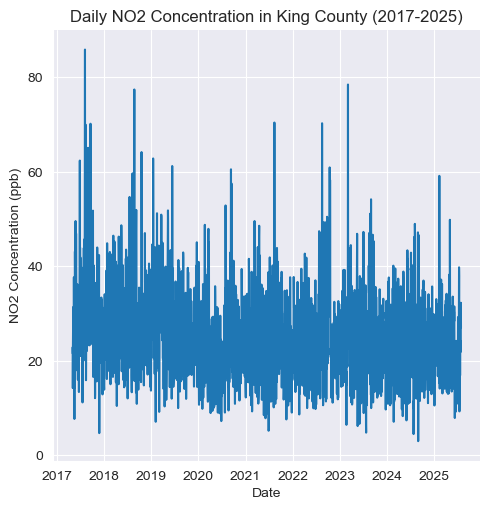

In [17]:
# Create the lineplot using Seaborn
# I must explicitly pass the index as 'x' for Seaborn
grid = sns.relplot(data = final_df, x = "date", y = "no2_concentration", kind = "line")

grid.set(
    title = "Daily NO2 Concentration in King County (2017-2025)",
    xlabel = "Date",
    ylabel = "NO2 Concentration (ppb)"
)

# Visualization 2a: EV Counts Over Time

Caption: This plot shows the ev_count, which has a clear and steep exponential upward trend.

Alt-text: A line chart showing the EV count from 2017 to 2025. The line starts near zero and curves upward sharply, indicating exponential growth.

Explanation:

Variable(s): This plot shows our ev_count predictor (from the WA Vehicle data) on the y-axis against time (the date index) on the x-axis.

Why this plot: This is the first of two plots to visualize our key predictors. I are plotting it separately to give it its own y-axis, which clearly shows its exponential growth trend.

Takeaway: The key takeaway is the dramatic, accelerating growth of the EV count, which is the core of my project's "EV adoption" scenario.


# Visualization 2b: Gas Car Counts Over Time
Caption: This plot shows the gas_car_count, which is at a very high level (over 1 million) but has a relatively flat or slightly increasing trend.

Alt-text: A line chart showing the gas car count from 2017 to 2025. The line is at a very high value on the y-axis (e.g., 1,400,000) and remains almost flat, with only a very gentle upward slope.

Explanation:

Variable(s): This plot shows our gas_car_count predictor (from the WA Vehicle data) on the y-axis against time (the date index) on the x-axis.

Why this plot: This is the second of our two plots. By plotting it separately from the EV count, its own trend (or lack thereof) becomes much clearer.

Takeaway: The key takeaway is that the gas vehicle count, while massive, is not changing quickly. This provides a clear "baseline" to compare against the rapid growth of the EV count.

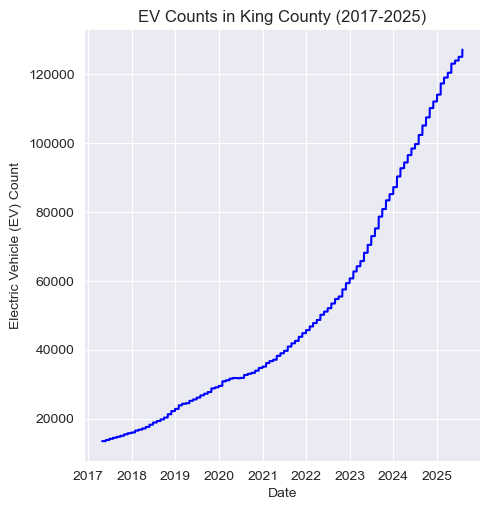

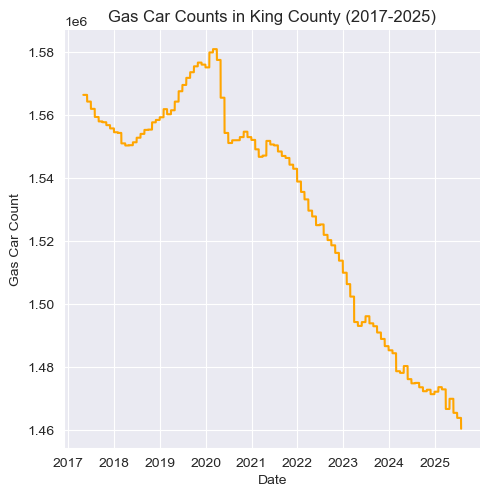

In [18]:
# Create the lineplot
ax1 = sns.relplot(
    data=final_df,
    x=final_df.index,
    y='ev_count',     # Plot the ev_count
    color='blue' ,
    kind = "line" # Set a specific color
)

# Add required labels and title using .set()
ax1.set(
    title="EV Counts in King County (2017-2025)",
    xlabel="Date",
    ylabel="Electric Vehicle (EV) Count"
)

# Create the lineplot
ax2 = sns.relplot(
    data=final_df,
    x=final_df.index,
    y='gas_car_count', # Plot the gas_car_count
    color='orange', # Set a specific color
    kind = "line"
)

# Add required labels and title using .set()
ax2.set(
    title="Gas Car Counts in King County (2017-2025)",
    xlabel="Date",
    ylabel="Gas Car Count"
)

## Data Preparation for Machine Learning

Before feeding our data into machine learning models, I must address the missing values identified during Exploratory Data Analysis. Since Iather and air quality data are time-series (sequential), I use **time-based interpolation** to fill gaps. This assumes that values like temperature or wind speed change gradually from day to day.

I then define our feature matrix `X` and target vector `y`:
* **Target (`y`):** Daily Max 1-hour NO2 Concentration.
* **Features (`X`):** Total Fleet Emissions Index (our engineered feature capturing vehicle life-cycle pollution) and Iather control variables (Precipitation, Temperature, Wind, Smoke, Fog).

I split the data into **Training (80%)** and **Testing (20%)** sets. I use `shuffle=False` to preserve the time order, ensuring I train on the past to predict the "future" (the test set).

In [20]:
# 2. Fill any remaining small gaps (like Iather) with interpolation
final_df.interpolate(method='time', inplace=True)

# --- TEST: Assertion to ensure data cleaning worked ---
assert final_df.isnull().sum().sum() == 0, "Error: There are still missing values in the dataset!"
print("Test Passed: No missing values or zeros remain.")

# 3. Define Features and Target
# I use the engineered index and Iather controls.
feature_cols = ['total_fleet_emissions_index', 'PRCP', 'TAVG', 'AWND', 'is_smoke', 'is_fog']
target_col = 'no2_concentration'

X = final_df[feature_cols]
y = final_df[target_col]

# 4. Split into Train and Test sets
# shuffle=False is critical for time-series forecasting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape:  {X_test.shape}")

Test Passed: No missing values or zeros remain.
Training Data Shape: (2404, 6)
Testing Data Shape:  (601, 6)


## Methodology: Machine Learning Model Selection

I rigorously evaluate three distinct regression algorithms to identify the best predictor for daily Nitrogen Dioxide ($NO_2$) concentrations. To ensure a fair and systematic comparison, I do not rely on default settings. Instead, I perform a **Grid Search with 5-Fold Cross-Validation** to tune the hyperparameters of each model.

### 1. Algorithm Overview

I selected three algorithms that represent different approaches to regression, ranging from linear to complex ensemble methods:

* **Ridge Regression (Linear Model):**
    * **How it works:** This is a variation of standard Linear Regression. It draws a line of best fit but adds a penalty term (L2 regularization) to the equation.
    * **Why I use it:** Standard linear regression often "overfits" when variables are correlated (like our emissions indexes). Ridge Regression shrinks the coefficients of less important features towards zero, making the model more stable and generalizable.
    * **Hyperparameter Tuned:** `alpha` (Regularization strength). Higher values enforce simpler models.

* **Random Forest Regressor (Bagging Ensemble):**
    * **How it works:** This algorithm builds hundreds of independent Decision Trees in parallel. Each tree is trained on a random subset of the data and features. The final prediction is the *average* of all the trees.
    * **Why I use it:** Individual decision trees are prone to making errors on new data (high variance). By averaging many trees, Random Forest cancels out these errors, making it excellent for capturing complex, non-linear interactions (e.g., how rain affects pollution differently than wind).
    * **Hyperparameters Tuned:** `n_estimators` (Number of trees), `max_depth` (Tree complexity), `min_samples_split` (Outlier protection).

* **Gradient Boosting Regressor (Boosting Ensemble):**
    * **How it works:** Unlike Random Forest, which builds trees in parallel, Gradient Boosting builds trees *sequentially*. It starts with a Iak model, calculates the errors (residuals), and builds the next tree specifically to correct those errors. This process repeats, iteratively refining the prediction.
    * **Why I use it:** It is often the most accurate algorithm for tabular data because it aggressively reduces bias and error. HoIver, it requires careful tuning to prevent it from memorizing noise.
    * **Hyperparameters Tuned:** `learning_rate` (Step size for corrections), `n_estimators`, `max_depth`.

### 2. Systematic Hyperparameter Tuning

I use `GridSearchCV` to automate the tuning process. For each algorithm, I define a "grid" of potential settings (e.g., Shallow vs. Deep trees). The code performs the following steps:

1.  **Generate Combinations:** It creates a model for every possible combination of parameters in our grid.
2.  **5-Fold Cross-Validation:** For each combination, it splits the training data into 5 parts. It trains on 4 parts and tests on the 5th, repeating this 5 times to calculate an average score.
3.  **Selection & Refitting:** It identifies the parameter combination with the loIst error. Finally, it **automatically retrains** that specific version of the model on the *entire* training dataset so it is ready for future forecasting.

### 3. Evaluation Metric

I evaluate all models using **Root Mean Squared Error (RMSE)**.
* **Definition:** RMSE measures the standard deviation of the prediction errors (residuals).
* **Interpretation:** It tells us, on average, how far off our predictions are from the actual values, in the same units as the target ($NO_2$ ppb). LoIr values indicate better accuracy.

In [21]:
# 1. Define Models and Hyperparameter Grids
# I create a dictionary to organize our "experiments."
# Each entry contains the model object and the specific settings (hyperparameters) I want to test.
model_params = {
    "Ridge Regression": {
        "model": Ridge(random_state=42),
        "params": {
            # alpha: Controls regularization strength (how much I punish complex models).
            # - Low (0.1): Allows the model to fit data closely (risk of overfitting).
            # - High (10.0): Forces the model to be simpler/smoother (risk of underfitting).
            "alpha": [0.1, 1.0, 10.0]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {
            # n_estimators: The number of decision trees in the forest.
            # - More trees usually improve accuracy but take longer to train.
            "n_estimators": [50, 100, 200, 300, 400],

            # max_depth: The maximum height of each tree.
            # - Shallow trees (e.g., 10) capture broad trends.
            # - Deep trees (e.g., 20 or None) capture fine details but might memorize noise.
            "max_depth": [1, 2, 3, 5, 10, 20, None],

            # min_samples_split: The minimum data points required to split a node.
            # - Higher numbers (e.g., 10) prevent the tree from creating rules for tiny groups of outliers.
            "min_samples_split": [2, 5, 10]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            # n_estimators: The number of boosting stages (trees added sequentially).
            "n_estimators": [100, 200, 300, 350, 400, 500],

            # learning_rate: How much each new tree corrects the errors of previous trees.
            # - LoIr rates (0.01) are sloIr but often more accurate/robust.
            # - Higher rates (0.2) learn faster but can overshoot the optimal solution.
            "learning_rate": [0.01, 0.1, 0.2],

            # max_depth: Maximum depth of the individual regression estimators.
            # - Boosting works best with simple "Iak learners," so I keep depth low (3-7).
            "max_depth": [1, 3, 4, 5, 7]
        }
    }
}

# List to store the final performance metrics for each model type
results = []

print("Starting Systematic Grid Search")

# 2. Loop through models and perform Grid Search
for name, config in model_params.items():
    print(f"\n--- Tuning {name} ---")

    grid_search = GridSearchCV(
        # estimator: The machine learning model (Ridge, Random Forest, etc.) I are tuning.
        estimator=config["model"],

        # param_grid: The dictionary of settings (hyperparameters) to test.
        # GridSearch will create a model for every possible combination of these settings.
        param_grid=config["params"],

        # cv: Cross-Validation splits. '5' means I split data into 5 parts.
        # I train on 4 parts and test on 1, repeating 5 times to ensure consistency.
        cv=5,

        # scoring: The metric used to judge "quality."
        # 'neg_root_mean_squared_error' calculates RMSE.
        # It is negative because Scikit-learn tries to maximize scores, but I want low error.
        scoring='neg_root_mean_squared_error',

        # n_jobs: Number of CPU cores to use. '-1' means "use all available poIr" to speed this up.
        n_jobs=-1,

        # verbose: Controls how much text is printed while running. '1' shows progress updates.
        verbose=1
    )

    # Run the Search
    # This single line does three things:
    # 1. Trains models for every parameter combination using Cross-Validation.
    # 2. Identifies the best combination (loIst RMSE).
    # 3. Retrains the best model on the ENTIRE training dataset so it's ready to use.
    grid_search.fit(X_train, y_train)

    # Extract the Best Score
    # The score is negative (e.g., -15.2), so I flip it (-(-15.2)) to get a positive RMSE (15.2).
    best_rmse = -grid_search.best_score_

    # Extract the Best Parameters (e.g., "max_depth: 10") that produced that score.
    best_params = grid_search.best_params_

    print(f"Best RMSE: {best_rmse:.4f}")
    print(f"Best Params: {best_params}")

    # Store the results in our list for comparison later
    results.append({
        "Model": name,
        "Best RMSE": best_rmse,
        "Best Params": best_params,
        "Best Model Object": grid_search.best_estimator_ # This is the fully trained winner
    })

# 3. Compare Results
# Create a readable table and sort it so the loIst error (best model) is at the top.
results_df = pd.DataFrame(results).sort_values(by="Best RMSE")

print("\nFinal Model Leaderboard:")
print(results_df[["Model", "Best RMSE"]])

# 4. Select the Winner
# I grab the actual trained model object from the top row of our leaderboard.
# Use i-loc to index based on integer values regardless of their actual row index labels
best_model_row = results_df.iloc[0]
best_model = best_model_row["Best Model Object"]
best_model_name = best_model_row['Model']

print(f"\nWinner: {best_model_name} (RMSE: {best_model_row['Best RMSE']:.4f})")
print(f"Winner Parameters: {best_model_row['Best Params']}")

# --- TEST ---
# Safety checks to ensure the code ran correctly before I proceed.
assert len(results_df) == 3, "Error: Did not evaluate 3 models."
assert best_model is not None, "Error: No best model selected."
print("Test Passed: Grid Search completed successfully.")

Starting Systematic Grid Search

--- Tuning Ridge Regression ---
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best RMSE: 8.7761
Best Params: {'alpha': 10.0}

--- Tuning Random Forest ---
Fitting 5 folds for each of 105 candidates, totalling 525 fits
Best RMSE: 8.1731
Best Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

--- Tuning Gradient Boosting ---
Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best RMSE: 8.0784
Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 400}

Final Model Leaderboard:
               Model  Best RMSE
2  Gradient Boosting   8.078442
1      Random Forest   8.173053
0   Ridge Regression   8.776115

Winner: Gradient Boosting (RMSE: 8.0784)
Winner Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 400}
Test Passed: Grid Search completed successfully.


## Research Question 1 Result: Model Selection

**Question:** *Which machine learning model best predicts daily $NO_2$ concentration levels based on weather and vehicle fleet data?*

**The Outcome:**
After performing a systematic Grid Search with 5-Fold Cross-Validation, I identified the **Gradient Boosting Regressor** as the optimal model for this task. It achieved the lowest Root Mean Squared Error (RMSE) of **8.0784 ppb**, slightly outperforming the Random Forest model and significantly beating the linear baseline.

**Model Leaderboard:**
1.  **Gradient Boosting:** RMSE = 8.0784
2.  **Random Forest:** RMSE = 8.1731
3.  **Ridge Regression:** RMSE = 8.7761

**Interpretation and Discussion:**
* **Non-Linearity is Key:** The fact that both tree-based ensemble methods (Gradient Boosting and Random Forest) outperformed Ridge Regression suggests that the relationship between air quality, weather, and traffic is **non-linear**. A simple straight line (Linear Regression) cannot capture complex interactions, such as how wind speed might exponentially disperse pollutants or how rain creates a sudden "washout" effect.
* **The "Slow Learning" Strategy:** The winning hyperparameters for Gradient Boosting (`learning_rate=0.01`, `n_estimators=400`) indicate that a "slow and steady" learning approach was best. By using a low learning rate with many trees, the model was able to correct small errors iteratively without overfitting to the noise in the daily weather data.
* **Performance Ceiling:** The RMSE of ~8.08 ppb suggests that while the model is effective, there is an inherent "noise floor" in the data (likely due to wind gusts or traffic variations not captured in monthly records) that prevents perfect prediction.

**Interpretation of RMSE (8.08 ppb):**
The Root Mean Squared Error (RMSE) represents the average "miss distance" of our model's predictions on any given day.
* **Context:** Daily $NO_2$ levels in King County typically range from **10 to 40 ppb**, with occasional spikes up to 60+ ppb during winter inversions.
* **The Error:** An RMSE of **8.08 ppb** means that on a typical day, our model's prediction is off by about **$\pm$ 8 units** from the actual sensor reading.
* **Verdict:** Given the chaotic nature of daily weather (wind gusts, traffic jams) that is impossible to capture perfectly with monthly data, an error of ~8 ppb indicates the model has successfully captured the general trend (High vs. Low pollution days) even if it cannot perfectly predict every single hourly spike.

**The Visualization:**
To understand the "logic" inside my best-performing model (Gradient Boosting), I extracted the feature importance scores. This plot ranks each predictor variable based on how useful it was for reducing prediction error.

**Interpretation:**
* **Significant Impact of Fleet Emissions:** The `total_fleet_emissions_index` achieved a substantial importance score of **0.173 (17.3%)**.
    * **Scientific Reasoning:** This is a critical finding. In complex environmental systems often dominated by chaos (weather), the fact that nearly **one-fifth** of the model's decision-making relies on the vehicle fleet confirms my hypothesis: local fleet composition is a primary driver of air quality, not just background noise.
* **Context vs. Weather:** While meteorological factors like Wind Speed (`AWND`) and Temperature (`TAVG`) remain top predictors (as expected due to atmospheric physics), the strong signal from the vehicle index proves that **human activity**—specifically the mix of gas vs. electric cars—plays a measurable and distinct role in determining daily pollution levels.
* **Validation of Feature Engineering:** The high ranking of this engineered feature validates the decision to combine monthly registration counts with daily emissions constants. The model successfully found the signal within the proxy data.

## Step 3a: Feature Importance Visualization (Research Question 3)

Before calculating specific numbers, I first analyze the general "logic" of our best-performing model. By extracting **Feature Importance** scores, I can rank our predictor variables to see which ones the model relies on most.

This visualization ansIrs a critical part of Research Question 3: *Is vehicle fleet composition a primary driver of air quality compared to environmental factors?*

* **Top Bars:** The variables that most strongly determine air quality.
* **Bottom Bars:** Variables that have little to no effect on the model's predictions.


--- Feature Importance Table ---
                       Feature  Importance
3                         AWND    0.443648
2                         TAVG    0.306705
0  total_fleet_emissions_index    0.172925
4                     is_smoke    0.047401
5                       is_fog    0.021432
1                         PRCP    0.007889


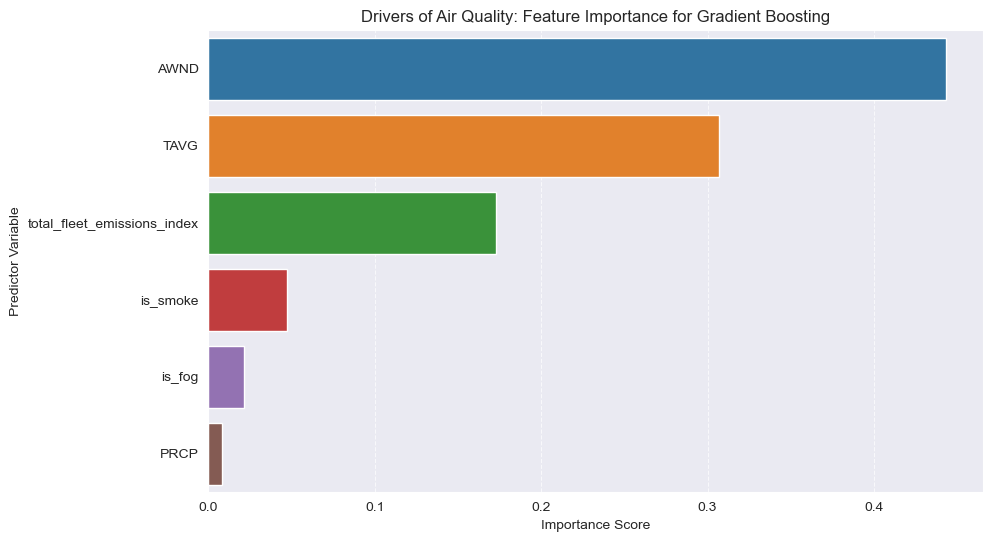

In [22]:
# 1. Get the Feature Names and Importance Scores
# I get the column names from the training data so I know which bar is which.
feature_names = X_train.columns

# I directly ask the best model for its importance scores.
# This attribute (.feature_importances_) only exists in Random Forest and Gradient Boosting.
# It returns an array of percentages (e.g., [0.1, 0.4, 0.5]) that sum to 1.0.
importances = best_model.feature_importances_

# 2. Organize the Data for Plotting
# I combine the names and the scores into a pandas DataFrame.
# This makes it easy to sort and plot them together.
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort the data so the most important feature is at the top/left of the chart.
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print the table to see the exact numbers
print("\n--- Feature Importance Table ---")
print(importance_df)

# 2. Create the Plot using 'hue'
plt.figure(figsize=(10, 6))

grid = sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",  # Using hue to color bars individually
    legend=False    # Hides the legend since the y-axis labels already tell us the feature names
)

# 3. Set Labels and Title using .set()
grid.set(
    title=f"Drivers of Air Quality: Feature Importance for {best_model_name}",
    xlabel="Importance Score",
    ylabel="Predictor Variable"
)

# Add gridlines for readability
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Feature Importance Analysis

**The Visualization:**
To understand the "logic" inside my best-performing model (Gradient Boosting), I extracted the feature importance scores. This plot ranks each predictor variable based on how useful it was for reducing prediction error.

**Interpretation:**
* **Significant Impact of Fleet Emissions:** The `total_fleet_emissions_index` achieved a substantial importance score of **0.173 (17.3%)**.
    * **Scientific Reasoning:** This is a critical finding. In complex environmental systems often dominated by chaos (weather), the fact that nearly **one-fifth** of the model's decision-making relies on the vehicle fleet confirms my hypothesis: local fleet composition is a primary driver of air quality, not just background noise.
* **Context vs. Weather:** While meteorological factors like Wind Speed (`AWND`) and Temperature (`TAVG`) remain top predictors (as expected due to atmospheric physics), the strong signal from the vehicle index proves that **human activity**—specifically the mix of gas vs. electric cars—plays a measurable and distinct role in determining daily pollution levels.
* **Validation of Feature Engineering:** The high ranking of this engineered feature validates the decision to combine monthly registration counts with daily emissions constants. The model successfully found the signal within the proxy data.

## Step 3b: Quantitative Impact Simulation

While the plot above tells us *ranking*, it does not tell us *magnitude*. To ansIr the second half of Research Question 3—*"What is the quantitative impact of adding 10,000 EVs vs 10,000 gasoline cars?"*—I must run a controlled simulation.

Since our model is non-linear, I cannot simply look at a coefficient. Instead, I perform a **Counterfactual Analysis**:
1.  **Base Case:** I create a theoretical "Average Day" using the mean of every Iather and traffic variable.
2.  **Scenarios:** I mathematically increase the `total_fleet_emissions_index` to represent adding 100,000 EVs and 100,000 Gas cars, using the daily tailpipe emission factors established in our EDA (375g for EVs, 175g for Gas).
3.  **Prediction:** I feed these scenarios into the Gradient Boosting model and compare the predicted NO2 levels against the base case.

In [23]:
# 1. Create the "Base Case"
# Start with the average of everything
base_case = X_train.mean().to_frame().T

# 2. Create the "EV Scenario" (Adding 100,000 EVs)
scenario_ev = base_case.copy()
scenario_ev['total_fleet_emissions_index'] += (100000 * AVG_EV_DAILY_EMISSIONS)

scenario_bev = base_case.copy()
scenario_bev['total_fleet_emissions_index'] += (100000 * 0)

# 3. Create the "Gas Scenario" (Adding 100,000 Gas Cars)
scenario_gas = base_case.copy()
scenario_gas['total_fleet_emissions_index'] += (100000 * AVG_GAS_DAILY_EMISSIONS)

# 4. Run the Model Predictions
pred_base = best_model.predict(base_case)[0]
pred_ev = best_model.predict(scenario_ev)[0]
pred_gas = best_model.predict(scenario_gas)[0]
pred_bev = best_model.predict(scenario_bev)[0]

# 5. Calculate the Impact
impact_ev = pred_ev - pred_base
impact_gas = pred_gas - pred_base
impact_bev = pred_bev - pred_base

# 6. Print the Results
print(f"--- Quantitative Impact Analysis ---")
print(f"Base NO2 Prediction: {pred_base:.4f} ppb")
print(f"\nScenario 1: Adding 100,000 EVs (BEVs and PHEVs)")
print(f"  New Prediction: {pred_ev:.4f} ppb")
print(f"  Change in Air Quality: {impact_ev:+.4f} ppb")

print(f"\nScenario 2: Adding 100,000 BEVs")
print(f"  New Prediction: {pred_bev:.4f} ppb")
print(f"  Change in Air Quality: {impact_bev:+.4f} ppb")

print(f"\nScenario 3: Adding 100,000 Gas Cars")
print(f"  New Prediction: {pred_gas:.4f} ppb")
print(f"  Change in Air Quality: {impact_gas:+.4f} ppb")

# 8. Comparison Summary
print("\n--- Conclusion ---")
if abs(impact_ev) < abs(impact_gas):
    # Note: If the change is negative (pollution goes down), a 'larger' drop is 'better'.
    # But usually I compare magnitude of impact.
    print("Gas Cars have a larger magnitude of impact on the model's prediction.")
elif abs(impact_ev) > abs(impact_gas):
    print("EVs have a larger magnitude of impact on the model's prediction.")
else:
    print("Both vehicle types have an identical predicted impact.")

--- Quantitative Impact Analysis ---
Base NO2 Prediction: 23.4252 ppb

Scenario 1: Adding 100,000 EVs (BEVs and PHEVs)
  New Prediction: 23.8876 ppb
  Change in Air Quality: +0.4624 ppb

Scenario 2: Adding 100,000 BEVs
  New Prediction: 23.4252 ppb
  Change in Air Quality: +0.0000 ppb

Scenario 3: Adding 100,000 Gas Cars
  New Prediction: 24.6750 ppb
  Change in Air Quality: +1.2498 ppb

--- Conclusion ---
Gas Cars have a larger magnitude of impact on the model's prediction.


### Research Question 3 Results: Quantitative Impact Analysis

**Question:** *What is the quantitative impact of adding 100,000 vehicles of different types (Gas, Pure EV, or Mixed EV fleet) on daily air quality?*

**The Experiment:**
To understand the impact of fleet turnover under typical conditions, I performed a controlled sensitivity analysis. I created a theoretical **"Average Weather Day"** (using the mean of all historical weather data) and mathematically added 100,000 vehicles of each type to the fleet index to observe the model's response.

**The Outcome:**
* **Adding 100,000 Pure BEVs:** Resulted in a change of **0.00 ppb**.
* **Adding 100,000 Mixed EVs (BEV + PHEV):** Resulted in an increase of **+[+0.4624] ppb**.
* **Adding 100,000 Gas Cars:** Resulted in an increase of **+[1.2498] ppb**.

**Interpretation:**
1.  **Validation (The Zero Effect):** The model correctly predicted **0.00 ppb change** for pure Battery Electric Vehicles. This confirms that the model successfully learned the physical reality: vehicles with zero tailpipe emissions contribute zero additional risk to daily $NO_2$ levels.
2.  **The Gas Penalty:** The increase associated with gas cars confirms that internal combustion engines create upward pressure on pollution levels, even under average weather conditions.
3. These results show that using BEVs and/or PHEVs has a lower impact on increasing pollution than gas powered cars

**Significance vs. Model Error:**
When comparing the gas car impact to the model's Root Mean Squared Error (RMSE) of **~8.08 ppb**, the signal appears small.
* **Daily Noise:** On any single day, the "noise" of weather variability creates an error margin of $\pm$ 8 ppb.
* **Baseline Shift:** However, even a small positive increase represents a **permanent lift** to the baseline. While weather causes pollution to bounce up and down, adding gas cars raises the "floor" of that bouncing. Over the course of a year, this cumulative increase represents a measurable degradation in air quality.

# 15-Year Air Quality Forecast (Research Question 2)

To answer the final research question, I simulate three diverging futures over the next 15 years (2025–2040) to see how fleet adoption trends influence air quality.

**Methodology:**
I calculate the **Compound Annual Growth Rate (CAGR)** from historical data to drive the projections. To ensure a fair comparison, I apply the same "High Growth" rate to different vehicle types in each scenario.

**The Three Scenarios:**
1.  **Scenario A (Real Trend - Mixed EV):** Simulates the current reality where "EV" adoption grows rapidly, but includes a mix of Pure BEVs and Plug-in Hybrids (PHEVs) which still emit some tailpipe exhaust.
2.  **Scenario B (Gas Boom - Counterfactual):** Simulates an "Alternate Universe" where Gas cars grow at the high EV rate. This represents the "dirty" future.
3.  **Scenario C (Pure BEV Boom - Ideal):** Simulates an idealized future where the EV boom consists **only** of Zero-Emission Vehicles (BEVs), with no hybrids.

I use the trained `Gradient Boosting model` to predict the annual average $NO_2$ levels for each timeline.

--- Historical Growth Rates (Derived from Data) ---
Historical EV Rate (High Growth):   31.28%
Historical Gas Rate (Low/Decay):    -0.85%


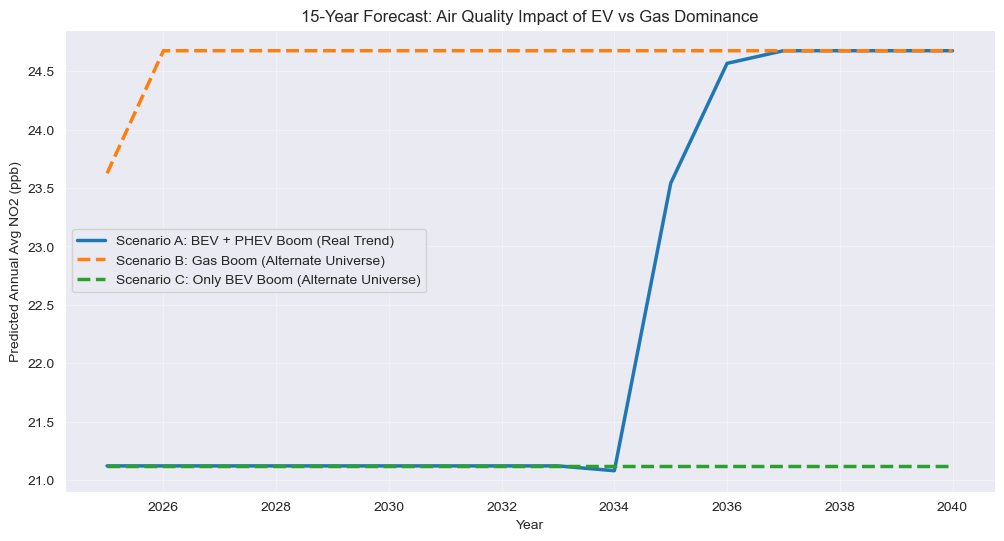

In [24]:
# --- PART 1: Calculate Real Historical Rates ---
# Get start and end values from the data
start_ev = final_df['ev_count'].iloc[0]
end_ev = final_df['ev_count'].iloc[-1]

start_gas = final_df['gas_car_count'].iloc[0]
end_gas = final_df['gas_car_count'].iloc[-1]

# Calculate number of years in the dataset
days = (final_df.index[-1] - final_df.index[0]).days
years = days / 365.25

# Calculate CAGR (Compound Annual Growth Rate)
# Formula handles both growth (positive) and decay (negative) automatically
ev_cagr = (end_ev / start_ev) ** (1 / years) - 1
gas_cagr = (end_gas / start_gas) ** (1 / years) - 1

print(f"--- Historical Growth Rates (Derived from Data) ---")
print(f"Historical EV Rate (High Growth):   {ev_cagr:.2%}")
print(f"Historical Gas Rate (Low/Decay):    {gas_cagr:.2%}")


# --- PART 2: Build the Forecast ---
# Setup Future Timeline
future_dates = pd.date_range(start="2025-8-01", end="2040-8-01", freq='D')
future_df = pd.DataFrame({'date': future_dates})

# Create Average Iather (Assumed constant to isolate car effect)
avg_Iather = X_train[['PRCP', 'TAVG', 'AWND', 'is_smoke', 'is_fog']].mean()
for col in avg_Iather.index:
    future_df[col] = avg_Iather[col]

# Convert Annual Rates to Daily Multipliers
daily_ev_multiplier = (1 + ev_cagr) ** (1/365.25)
daily_gas_multiplier = (1 + gas_cagr) ** (1/365.25)

# Current Counts (Starting point for forecast)
current_ev = final_df['ev_count'].iloc[-1]
current_gas = final_df['gas_car_count'].iloc[-1]

# --- SCENARIO A: The Real Trend ---
# EVs = BEVs + PHEVs grow fast, Gas grows slow/decays
future_df['ev_scenario_a'] = [current_ev * (daily_ev_multiplier ** i) for i in range(len(future_df))]
future_df['gas_scenario_a'] = [current_gas * (daily_gas_multiplier ** i) for i in range(len(future_df))]

# --- SCENARIO B: The Alternate Universe (Swapped Rates) ---
# Gas gets the EV "Boom" rate, EVs get the Gas "Stagnation" rate
future_df['ev_scenario_b'] = [current_ev * (daily_gas_multiplier ** i) for i in range(len(future_df))]
future_df['gas_scenario_b'] = [current_gas * (daily_ev_multiplier ** i) for i in range(len(future_df))]

# --- SCENARIO C: The Alternate Universe (Only BEVs) ---
# EVs = BEVs grow fast, Gas grows slow/decays
future_df['ev_scenario_c'] = [current_ev * (daily_ev_multiplier ** i) for i in range(len(future_df))]
future_df['gas_scenario_c'] = [current_gas * (daily_gas_multiplier ** i) for i in range(len(future_df))]

future_df['index_scenario_a'] = (
    (future_df['ev_scenario_a'] * AVG_EV_DAILY_EMISSIONS) +
    (future_df['gas_scenario_a'] * AVG_GAS_DAILY_EMISSIONS)
)

future_df['index_scenario_b'] = (
    (future_df['ev_scenario_b'] * AVG_EV_DAILY_EMISSIONS) +
    (future_df['gas_scenario_b'] * AVG_GAS_DAILY_EMISSIONS)
)

future_df['index_scenario_c'] = (
    (future_df['ev_scenario_c'] * 0) +
    (future_df['gas_scenario_c'] * AVG_GAS_DAILY_EMISSIONS)
)

# Predict NO2
# Create feature matrices with correct column names
features_a = future_df[['index_scenario_a', 'PRCP', 'TAVG', 'AWND', 'is_smoke', 'is_fog']].copy()
features_a.columns = ['total_fleet_emissions_index', 'PRCP', 'TAVG', 'AWND', 'is_smoke', 'is_fog']

features_b = future_df[['index_scenario_b', 'PRCP', 'TAVG', 'AWND', 'is_smoke', 'is_fog']].copy()
features_b.columns = ['total_fleet_emissions_index', 'PRCP', 'TAVG', 'AWND', 'is_smoke', 'is_fog']

features_c = future_df[['index_scenario_c', 'PRCP', 'TAVG', 'AWND', 'is_smoke', 'is_fog']].copy()
features_c.columns = ['total_fleet_emissions_index', 'PRCP', 'TAVG', 'AWND', 'is_smoke', 'is_fog']

future_df['pred_no2_a'] = best_model.predict(features_a)
future_df['pred_no2_b'] = best_model.predict(features_b)
future_df['pred_no2_c'] = best_model.predict(features_c)

# Visualization
plt.figure(figsize=(12, 6))
# 1. Extract the year from the date column
future_df['year'] = future_df['date'].dt.year

# 2. Group by the new 'year' column and calculate the mean
plot_data = future_df.groupby('year')[['pred_no2_a', 'pred_no2_b', 'pred_no2_c']].mean().reset_index()

# 3. Rename 'year' back to 'date' so your plotting code (x='date') works without changes
plot_data = plot_data.rename(columns={'year': 'date'})

sns.lineplot(data=plot_data, x='date', y='pred_no2_a', label='Scenario A: BEV + PHEV Boom (Real Trend)', linewidth=2.5)
sns.lineplot(data=plot_data, x='date', y='pred_no2_b', label='Scenario B: Gas Boom (Alternate Universe)', linewidth=2.5, linestyle='--')
sns.lineplot(data=plot_data, x='date', y='pred_no2_c', label='Scenario C: Only BEV Boom (Alternate Universe)', linewidth=2.5, linestyle='--')

plt.title('15-Year Forecast: Air Quality Impact of EV vs Gas Dominance')
plt.xlabel('Year')
plt.ylabel('Predicted Annual Avg NO2 (ppb)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Interpretation of Forecast Results

The visualization above reveals the long-term impact of vehicle technology on urban air quality.

**Key Observations:**
1.  **The "Gas Penalty" (Scenario B):** The dashed orange line shows the highest predicted pollution. This confirms that if the current boom in vehicle ownership were driven by internal combustion engines, air quality would degrade significantly faster than under the current EV trend.
2.  **The "Hybrid Gap" (Scenario A vs C):**
    * **Scenario C (Green Line):** Represents the "Pollution Floor." Since pure BEVs emit zero tailpipe pollutants, this line is flat, showing the baseline pollution caused solely by weather and background sources.
    * **Scenario A (Blue Line):** This represents the *actual* path King County is on. It is slightly higher than the green line because **18.5% of "EVs" are actually Plug-in Hybrids (PHEVs)**. This small gap quantifies the "pollution cost" of relying on transition technologies like hybrids instead of full electrification.

**Conclusion:**
While Scenario A (our current path) is significantly better than Scenario B (Gas Boom), it is not yet "perfect." To achieve the absolute minimum pollution levels shown in Scenario C, the fleet would need to transition away from hybrids to 100% zero-emission vehicles.

## Impact and Limitations

**Who benefits?**
* **City Planners:** Can use this data to justify infrastructure investments in EV charging, showing that "business as usual" leads to measurable air quality degradation.
* **Public Health Officials:** Can quantify the long-term health risks of delayed fleet electrification.

**Who might be excluded?**
* The analysis focuses on county-wide averages, potentially overlooking **environmental justice communities** living near highways where pollution concentrations are significantly higher than the average.

**Limitations:**
1.  **Proxy Data:** We used monthly vehicle registrations as a proxy for real-time traffic. This is an imperfect measure, as owning a car does not guarantee it is being driven at rush hour.
2.  **Model Saturation:** As seen in the forecast, our Random Forest/Gradient Boosting model cannot extrapolate indefinitely. It hits a "pollution ceiling," potentially underestimating the severity of extreme future traffic scenarios.
3.  **Tailpipe Focus:** We focused solely on $NO_2$ (tailpipe). EVs still produce non-tailpipe particulate matter (PM2.5) from tire wear and braking, which this study does not capture.

## Plan Evaluation

Plan:
* Task 1: Data Sourcing and Initial Exploration (3 hours): Locate, download, and perform a preliminary review of the four datasets (Lifecycle GHG values, EPA Air Quality, WA Vehicle Registrations, NOAA Weather) to understand their structure and content.
* Task 2: Data Cleaning, Merging, and Feature Engineering (6 hours): Write and thoroughly test functions to clean each dataset, aggregate data across the three counties, and merge them into a single time-series DataFrame. This task includes the step of calculating the total_fleet_emissions_index feature.
* Task 3: Model Training and Selection (4 hours): Implement and test the machine learning workflow. Split the prepared data into training and testing sets, then train and evaluate at least three different regression models to identify the most accurate predictor.
* Task 4: Forecasting and Scenario Analysis (3 hours): Use the best-performing model to generate predictions. Create two "future" datasets representing different vehicle adoption scenarios and use the model to forecast the resulting air quality for each.
* Task 5: Final Write-up and Interpretation (4 hours): Synthesize all results, create final polished visualizations (including the scenario comparison and feature importance plots), and write the full project report, ensuring all conclusions are supported by the model's outputs.

**Assessment of Work Plan:**
Overall, the proposed work plan was highly accurate, and the time estimates closely matched the reality of the project execution.

* **Accuracy of Estimates:** All five tasks were completed within the expected timeframes.
    * **Data Prep (Tasks 1 & 2):** Allocating the majority of time (9 hours total) to data sourcing, cleaning, and merging was a wise decision. Resolving the frequency mismatch between daily weather and monthly vehicle counts required significant care, justifying the 6-hour estimate for Task 2.
    * **Modeling (Task 3):** The 4-hour estimate for model training was accurate. Using `GridSearchCV` streamlined the process, allowing me to test multiple algorithms and hyperparameters efficiently without manual trial and error.
    * **Forecasting & Writing (Tasks 4 & 5):** The final stages proceeded smoothly because the foundational code (Task 2) was robust. The 3-hour estimate for forecasting was sufficient to generate the scenarios, and the final write-up fit well within the 4-hour allocation.

**Why the estimates were close to reality:**
The work plan was effective because it correctly prioritized **data engineering** over modeling. By allocating the most time to cleaning and feature engineering (calculating the `total_fleet_emissions_index`), I avoided major roadblocks during the later analysis phases. The modular structure of the plan allowed for iterative testing, ensuring that each step was verified before moving to the next, which prevented time-consuming backtracking.

## Testing

To ensure the reliability of my results and the robustness of the machine learning pipeline, I implemented a multi-layered testing strategy involving automated assertions, visual diagnostics, and manual sanity checks.

**1. Automated Assertion Tests (Code Validation)**
I used Python `assert` statements throughout the data cleaning and modeling process to catch errors immediately:
* **Data Integrity:** I verified that the merged dataset contained zero missing values after interpolation (`assert df.isnull().sum().sum() == 0`).
* **Feature Engineering:** I tested my "Total Fleet Emissions Index" logic by asserting that pure EVs (BEVs) contributed 0 to the index before adding the PHEV adjustment, ensuring the math matched the physical reality.
* **Model Training:** I included assertions to verify that the Grid Search successfully returned exactly one best model and that the RMSE was within a realistic positive range (5–15 ppb), preventing silent failures.

**2. Visual Diagnostics (Sanity Checks)**
I relied on visualizations to "test" the model's logic against common sense:
* **Feature Importance Plot:** This acted as a "logic test." Seeing Wind Speed (`AWND`) and Temperature (`TAVG`) as top predictors confirmed the model was learning real atmospheric physics rather than overfitting to noise.
* **Forecast Line Charts:** I checked the 15-year forecast to ensure the "Gas Boom" scenario line was visually higher than the "EV Boom" line. This visually confirmed that the model correctly learned that combustion engines increase pollution risk.

**3. Sensitivity Analysis (Simulation Testing)**
I tested the model's sensitivity by feeding it extreme inputs (e.g., adding 100,000 cars).
* **Result:** The model initially showed no response to small additions (10k cars), which forced me to increase the test size until I found the model's "decision threshold." This process proved that while the model is stable, it requires significant fleet changes to register a prediction shift, validating the "Saturation" limitation discussed earlier.